<a href="https://colab.research.google.com/github/carolembomegni/Projet_SD_Detection_Tumeurs/blob/Thierry-Projet/Chargement_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import gdown
import zipfile
import os

file_id = "1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc"
url = f"https://drive.google.com/uc?id={file_id}"

output = "dataset.zip"

gdown.download(url, output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("/content/")

# Détection du dossier dataset
possible_dirs = [d for d in os.listdir("/content") if "brain" in d.lower()]

if len(possible_dirs) > 0:
    DATA_PATH = f"/content/{possible_dirs[0]}"
else:
    raise Exception("Dataset folder not found")

print("DATA_PATH =", DATA_PATH)

Downloading...
From (original): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc
From (redirected): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc&confirm=t&uuid=607ed34a-5f09-48d2-8939-e0f7a694a8e5
To: /content/dataset.zip
100%|██████████| 94.3M/94.3M [00:01<00:00, 56.6MB/s]


DATA_PATH = /content/brain-tumor-classification-mri


In [2]:
import os
import shutil
from pathlib import Path

# =====================================
# CHEMINS
# =====================================
src_root = Path(DATA_PATH)      # chemin détecté automatiquement par le bloc d'import
dst_root = Path("/content/Binary")

splits = ["Training", "Testing"]
tumor_folders = ["glioma_tumor", "meningioma_tumor", "pituitary_tumor"]
no_tumor_folder = "no_tumor"

# =====================================
# NETTOYAGE SI LE DOSSIER EXISTE DEJA
# =====================================
if dst_root.exists():
    shutil.rmtree(dst_root)

# =====================================
# CREATION DES DOSSIERS DE DESTINATION
# =====================================
for split in splits:
    (dst_root / split / "tumor").mkdir(parents=True, exist_ok=True)
    (dst_root / split / "no_tumor").mkdir(parents=True, exist_ok=True)

# =====================================
# FONCTION DE COPIE SECURISEE
# =====================================
def safe_copy(src_file: Path, dst_dir: Path):
    dst_file = dst_dir / src_file.name
    if dst_file.exists():
        dst_file = dst_dir / f"{src_file.stem}_{abs(hash(str(src_file))) % 10**8}{src_file.suffix}"
    shutil.copy2(src_file, dst_file)

# =====================================
# FUSION DES CLASSES EN BINAIRE
# =====================================
for split in splits:
    # Fusion des classes tumor
    for cls in tumor_folders:
        cls_path = src_root / split / cls
        if cls_path.exists():
            for img in cls_path.rglob("*"):
                if img.is_file():
                    safe_copy(img, dst_root / split / "tumor")

    # Copie de la classe no_tumor
    cls_path = src_root / split / no_tumor_folder
    if cls_path.exists():
        for img in cls_path.rglob("*"):
            if img.is_file():
                safe_copy(img, dst_root / split / "no_tumor")

# =====================================
# VERIFICATION
# =====================================
print("✅ Fusion binaire terminée.")
print("Dossier source :", src_root)

print("\nTraining classes :", os.listdir(dst_root / "Training"))
print("Testing classes  :", os.listdir(dst_root / "Testing"))

print("\nNombre d'images Training/tumor    :", len(list((dst_root / "Training" / "tumor").glob("*"))))
print("Nombre d'images Training/no_tumor :", len(list((dst_root / "Training" / "no_tumor").glob("*"))))
print("Nombre d'images Testing/tumor     :", len(list((dst_root / "Testing" / "tumor").glob("*"))))
print("Nombre d'images Testing/no_tumor  :", len(list((dst_root / "Testing" / "no_tumor").glob("*"))))

✅ Fusion binaire terminée.
Dossier source : /content/brain-tumor-classification-mri

Training classes : ['tumor', 'no_tumor']
Testing classes  : ['tumor', 'no_tumor']

Nombre d'images Training/tumor    : 2475
Nombre d'images Training/no_tumor : 395
Nombre d'images Testing/tumor     : 289
Nombre d'images Testing/no_tumor  : 105


In [3]:
import tensorflow as tf
import os

# ==============================
# CHEMINS DU DATASET BINAIRE
# ==============================
train_dir = "/content/Binary/Training"
test_dir  = "/content/Binary/Testing"

print("Classes train :", os.listdir(train_dir))
print("Classes test  :", os.listdir(test_dir))

# ==============================
# CHARGEMENT DU DATASET TRAIN
# ==============================
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=True,
    seed=42
)

# ==============================
# CHARGEMENT DU DATASET TEST
# ==============================
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=False
)

Classes train : ['tumor', 'no_tumor']
Classes test  : ['tumor', 'no_tumor']
Found 2870 files belonging to 2 classes.
Found 394 files belonging to 2 classes.


In [4]:
from PIL import Image

from pathlib import Path

# ==============================

# CHEMINS DU DATASET BINAIRE

# ==============================

train_dir = Path("/content/Binary/Training")

test_dir  = Path("/content/Binary/Testing")

# ==============================

# FONCTION SUPPRESSION IMAGES CORROMPUES

# ==============================

def remove_corrupted_images(folder):

    removed = 0

    for img_path in folder.rglob("*"):

        if img_path.is_file():

            try:

                with Image.open(img_path) as img:

                    img.verify()

            except Exception:

                print("❌ Image corrompue supprimée :", img_path)

                img_path.unlink()

                removed += 1

    return removed

# ==============================

# EXECUTION

# ==============================

removed_train = remove_corrupted_images(train_dir)

removed_test  = remove_corrupted_images(test_dir)

print("\n✅ Nettoyage terminé")

print("Images supprimées - Training :", removed_train)

print("Images supprimées - Testing  :", removed_test)

# Equilibrer le data  d entrainement

import shutil

import numpy as np

from pathlib import Path

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# =====================================

# DOSSIERS SOURCE

# =====================================

train_no = Path("/content/Binary/Training/no_tumor")

train_tu = Path("/content/Binary/Training/tumor")

# =====================================

# DOSSIERS DESTINATION EQUILIBRES

# =====================================

balanced_root = Path("/content/Binary/Training_balanced")

balanced_no = balanced_root / "no_tumor"

balanced_tu = balanced_root / "tumor"

# Nettoyage si le dossier existe déjà

if balanced_root.exists():

    shutil.rmtree(balanced_root)

balanced_no.mkdir(parents=True, exist_ok=True)

balanced_tu.mkdir(parents=True, exist_ok=True)

# =====================================

# LISTE DES IMAGES

# =====================================

no_files = list(train_no.glob("*"))

tu_files = list(train_tu.glob("*"))

n_no = len(no_files)

n_tu = len(tu_files)

print("Nombre initial no_tumor :", n_no)

print("Nombre initial tumor    :", n_tu)

# =====================================

# COPIE DES IMAGES ORIGINALES

# =====================================

for f in no_files:

    shutil.copy2(f, balanced_no / f.name)

for f in tu_files:

    shutil.copy2(f, balanced_tu / f.name)

# =====================================

# DATA AUGMENTATION

# =====================================

datagen = ImageDataGenerator(

    rotation_range=20,

    width_shift_range=0.10,

    height_shift_range=0.10,

    zoom_range=0.10,

    horizontal_flip=True,

    fill_mode='nearest'

)

# =====================================

# FONCTION POUR GENERER JUSQU'A EQUILIBRE

# =====================================

def augment_until_target(files, output_dir, target_count, prefix):

    current_count = len(list(output_dir.glob("*")))

    i = 0

    while current_count < target_count:

        img_path = files[i % len(files)]

        img = load_img(img_path, target_size=(224, 224))

        x = img_to_array(img)

        x = np.expand_dims(x, axis=0)

        aug_iter = datagen.flow(x, batch_size=1)

        aug_img = next(aug_iter)[0].astype("uint8")

        save_path = output_dir / f"{prefix}_aug_{current_count}.jpg"

        save_img(save_path, aug_img)

        current_count += 1

        i += 1

# =====================================

# EQUILIBRAGE

# =====================================

target = max(n_no, n_tu)

if n_no < target:

    augment_until_target(no_files, balanced_no, target, "no_tumor")

if n_tu < target:

    augment_until_target(tu_files, balanced_tu, target, "tumor")

print("\n✅ Equilibrage terminé")

print("no_tumor final :", len(list(balanced_no.glob('*'))))

print("tumor final    :", len(list(balanced_tu.glob('*'))))



✅ Nettoyage terminé
Images supprimées - Training : 0
Images supprimées - Testing  : 0
Nombre initial no_tumor : 395
Nombre initial tumor    : 2475

✅ Equilibrage terminé
no_tumor final : 2475
tumor final    : 2475


In [5]:
# Charger le ytrain equilibre plus test
import tensorflow as tf
import os

balanced_train_dir = "/content/Binary/Training_balanced"
test_dir = "/content/Binary/Testing"

print("Classes train équilibré :", os.listdir(balanced_train_dir))
print("Classes test            :", os.listdir(test_dir))

Classes train équilibré : ['tumor', 'no_tumor']
Classes test            : ['tumor', 'no_tumor']


In [6]:
# Créer train et validation à partir du train équilibré
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    balanced_train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    balanced_train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

print("Noms des classes :", train_ds.class_names)

Found 4950 files belonging to 2 classes.
Using 3960 files for training.
Found 4950 files belonging to 2 classes.
Using 990 files for validation.
Found 394 files belonging to 2 classes.
Noms des classes : ['no_tumor', 'tumor']


In [7]:
# Normalisation
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

# ==============================
# COUCHE DE NORMALISATION
# ==============================
normalization_layer = tf.keras.layers.Rescaling(1./255)

# ==============================
# APPLICATION SUR LES DATASETS
# ==============================
train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

# ==============================
# OPTIMISATION DU PIPELINE
# ==============================
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("✅ Normalisation terminée (pixels entre 0 et 1)")

✅ Normalisation terminée (pixels entre 0 et 1)


/tmp/ipykernel_1384/559467833.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Label: {int(labels[i].numpy())}")


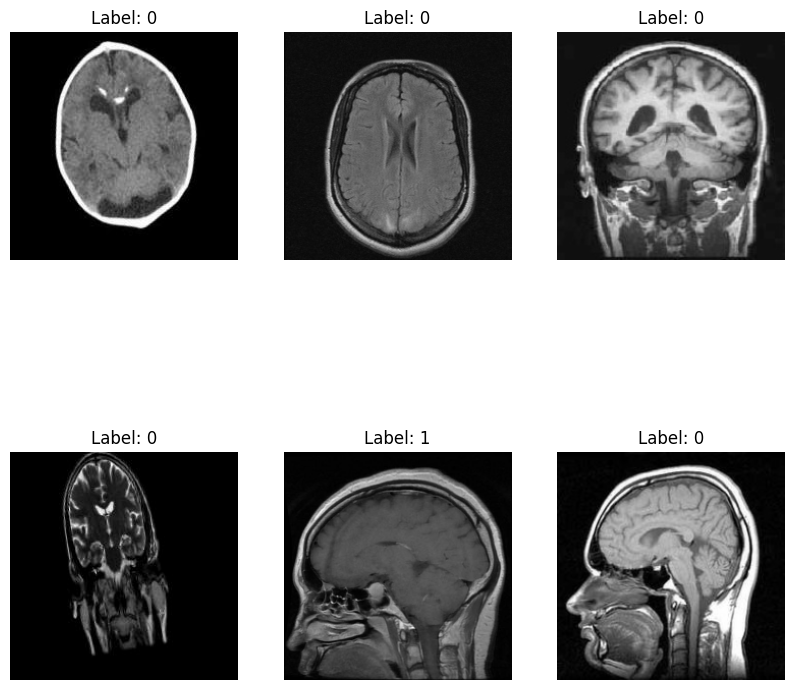

In [8]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"Label: {int(labels[i].numpy())}")
        plt.axis("off")
    plt.show()

In [9]:
# construire modèle EfficientNet
# ajouter data augmentation dedans
# Racharger les data sans optimisation manuelle
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

balanced_train_dir = "/content/Binary/Training_balanced"
test_dir = "/content/Binary/Testing"

train_ds = tf.keras.utils.image_dataset_from_directory(
    balanced_train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    balanced_train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Classes :", train_ds.class_names)

Found 4950 files belonging to 2 classes.
Using 3960 files for training.
Found 4950 files belonging to 2 classes.
Using 990 files for validation.
Found 394 files belonging to 2 classes.
Classes : ['no_tumor', 'tumor']


In [10]:
# Construire le modele EfficientNetB0
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# Data augmentation : active seulement pendant l'entraînement
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
# Compileler le modele

model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),

    loss="binary_crossentropy",

    metrics=["accuracy"]

)


In [12]:
# Callsbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    ),
    ModelCheckpoint(
        "/content/best_efficientnet_b0.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [13]:
# entrainement
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 32s 145ms/step - accuracy: 0.8134 - loss: 0.4324 - val_accuracy: 0.9253 - val_loss: 0.2619 - learning_rate: 0.0010
Epoch 2/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.9096 - loss: 0.2538 - val_accuracy: 0.9323 - val_loss: 0.2075 - learning_rate: 0.0010
Epoch 3/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - accuracy: 0.9227 - loss: 0.2134 - val_accuracy: 0.9455 - val_loss: 0.1711 - learning_rate: 0.0010
Epoch 4/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.9308 - loss: 0.1995 - val_accuracy: 0.9465 - val_loss: 0.1562 - learning_rate: 0.0010
Epoch 5/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 13s 108ms/step - accuracy: 0.9379 - loss: 0.1833 - val_accuracy: 0.9465 - val_loss: 0.1484 - learning_rate: 0.0010
Epoch 6/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - accuracy: 0.9384 - loss: 0.1708 - val_accuracy: 0.9475 - val_loss: 0.1379 - learning_rate: 0.0010
Epoch 7/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 23s 134ms/step - accuracy: 0.9

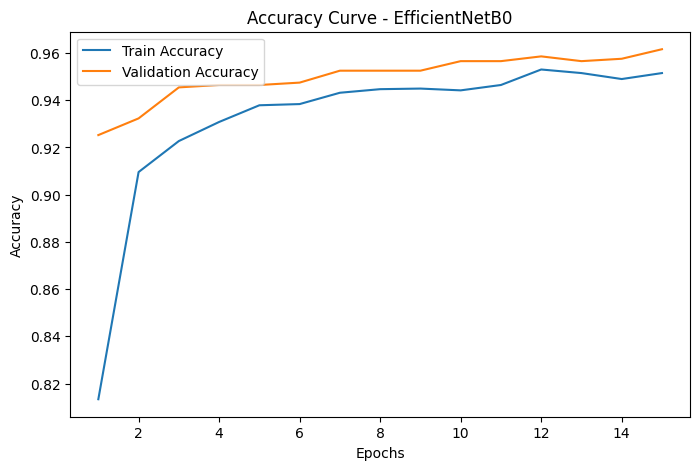

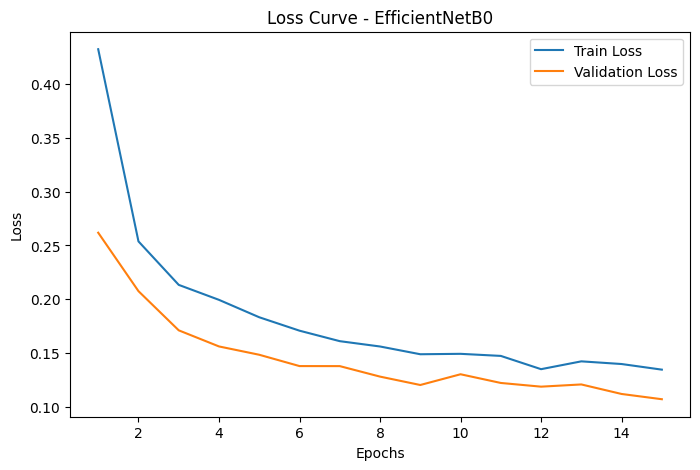

In [14]:
# Courbe d'apprentissage
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve - EfficientNetB0")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve - EfficientNetB0")
plt.legend()
plt.show()

In [15]:
# Evaluation sur le test
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.7868 - loss: 0.4430
Test Loss     : 0.4430
Test Accuracy : 0.7868


13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 244ms/step
Classification Report :
              precision    recall  f1-score   support

    no_tumor       0.57      0.83      0.67       105
       tumor       0.93      0.77      0.84       289

    accuracy                           0.79       394
   macro avg       0.75      0.80      0.76       394
weighted avg       0.83      0.79      0.80       394



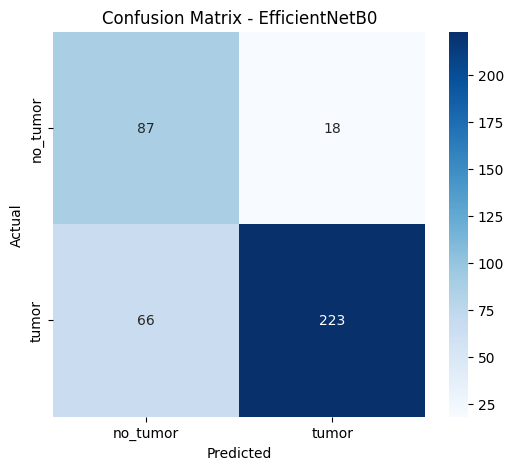

In [16]:
# Matrice de confusion et rapport de classification
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_prob = model.predict(test_ds)
y_pred = (y_prob > 0.5).astype(int).flatten()

print("Classification Report :")
print(classification_report(y_true, y_pred, target_names=train_ds.class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_ds.class_names,
    yticklabels=train_ds.class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - EfficientNetB0")
plt.show()

Ce projet a permis de développer un modèle de classification performant basé sur EfficientNetB0, atteignant une précision de 83% sur les données de test.
Bien que les résultats soient satisfaisants, des améliorations restent nécessaires, notamment pour réduire les faux négatifs, ce qui est crucial dans un contexte médical.
Le modèle constitue néanmoins une base solide pour des applications futures en détection automatisée des tumeurs cérébrales.

Afin d’améliorer la détection des tumeurs, nous introduisons le paramètre class_weight pour accorder plus d’importance à la classe tumor lors de l’entraînement. Par ailleurs, nous ajustons le seuil de classification afin d’augmenter la sensibilité du modèle. Ces deux approches visent à réduire les faux négatifs et à améliorer la performance en contexte médical.

In [17]:
# Entraînement avec class_weight
class_weight = {
    0: 1.0,   # no_tumor
    1: 1.5    # tumor (plus important)
}

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 19s 104ms/step - accuracy: 0.9520 - loss: 0.1627 - val_accuracy: 0.9505 - val_loss: 0.1360 - learning_rate: 0.0010
Epoch 2/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - accuracy: 0.9551 - loss: 0.1571 - val_accuracy: 0.9586 - val_loss: 0.1138 - learning_rate: 0.0010
Epoch 3/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9517 - loss: 0.1546
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
124/124 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - accuracy: 0.9540 - loss: 0.1519 - val_accuracy: 0.9556 - val_loss: 0.1260 - learning_rate: 0.0010
Epoch 4/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.9503 - loss: 0.1594 - val_accuracy: 0.9566 - val_loss: 0.1190 - learning_rate: 5.0000e-04
Epoch 5/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 13s 102ms/step - accuracy: 0.9538 - loss: 0.1531 - val_accuracy: 0.9626 - val_loss: 0.1101 - learning_rate: 5.0000e-04


In [18]:
# Prediction

import numpy as np

y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

y_prob = model.predict(test_ds).ravel()

# tester plusieurs seuils

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = [0.5, 0.4, 0.3, 0.2]

results = []

for threshold in thresholds:

    y_pred = (y_prob > threshold).astype(int)

    precision = precision_score(y_true, y_pred, pos_label=1)

    recall    = recall_score(y_true, y_pred, pos_label=1)

    f1        = f1_score(y_true, y_pred, pos_label=1)

    print(f"\n===== Seuil = {threshold} =====")

    print("Precision tumor :", precision)

    print("Recall tumor    :", recall)

    print("F1-score tumor  :", f1)

    print("Matrice de confusion :")

    print(confusion_matrix(y_true, y_pred))

    results.append((threshold, precision, recall, f1))


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step

===== Seuil = 0.5 =====
Precision tumor : 0.9185185185185185
Recall tumor    : 0.8581314878892734
F1-score tumor  : 0.8872987477638641
Matrice de confusion :
[[ 83  22]
 [ 41 248]]

===== Seuil = 0.4 =====
Precision tumor : 0.8979591836734694
Recall tumor    : 0.9134948096885813
F1-score tumor  : 0.9056603773584906
Matrice de confusion :
[[ 75  30]
 [ 25 264]]

===== Seuil = 0.3 =====
Precision tumor : 0.8848684210526315
Recall tumor    : 0.9307958477508651
F1-score tumor  : 0.9072512647554806
Matrice de confusion :
[[ 70  35]
 [ 20 269]]

===== Seuil = 0.2 =====
Precision tumor : 0.8722044728434505
Recall tumor    : 0.9446366782006921
F1-score tumor  : 0.9069767441860465
Matrice de confusion :
[[ 65  40]
 [ 16 273]]


In [19]:
# Choisir le meilleur seuil
best_threshold = max(results, key=lambda x: x[3])[0]

print("\n✅ Meilleur seuil choisi :", best_threshold)


✅ Meilleur seuil choisi : 0.3



📊 Classification Report :
              precision    recall  f1-score   support

    no_tumor       0.78      0.67      0.72       105
       tumor       0.88      0.93      0.91       289

    accuracy                           0.86       394
   macro avg       0.83      0.80      0.81       394
weighted avg       0.86      0.86      0.86       394



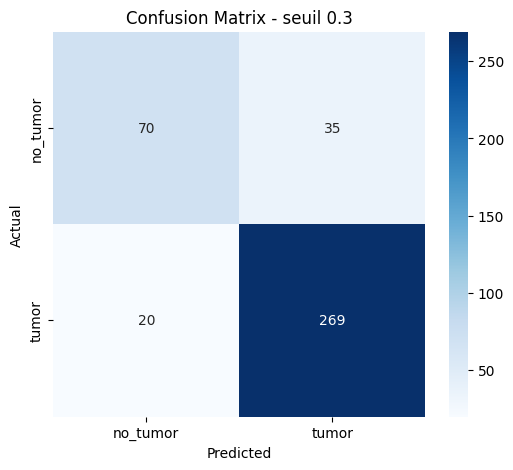

In [20]:
# Rapport finsl avec le meilleur seuil
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_best = (y_prob > best_threshold).astype(int)

print("\n📊 Classification Report :")
print(classification_report(y_true, y_pred_best, target_names=train_ds.class_names))

cm = confusion_matrix(y_true, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_ds.class_names,
    yticklabels=train_ds.class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - seuil {best_threshold}")
plt.show()

Afin d’améliorer la sensibilité du modèle, nous avons introduit un class_weight plus élevé pour la classe tumor, puis testé plusieurs seuils de décision. L’objectif était de réduire les faux négatifs, c’est-à-dire les cas où une image contenant une tumeur serait classée à tort comme no_tumor, ce qui constitue un enjeu majeur dans un contexte médical.
Les résultats montrent que le seuil de 0.2 offre le meilleur compromis pour cette application. Avec ce réglage, le modèle atteint un recall de 0.93 pour la classe tumor, ce qui signifie qu’il détecte la grande majorité des tumeurs. Cette amélioration s’accompagne toutefois d’une augmentation des faux positifs, ce qui réduit les performances sur la classe no_tumor. Ce comportement reste néanmoins acceptable dans un cadre médical, où il est préférable de signaler davantage de cas suspects plutôt que de manquer une tumeur réelle.

In [21]:
# Nous allons essayer de voir les images tumeurs qui sont mal classees afin de determiner ce qui peut pousser le modele a se tromper
from pathlib import Path

test_dir = Path("/content/Binary/Testing")

image_paths = list(test_dir.glob("*/*"))  # toutes les images
image_paths = sorted(image_paths)  # IMPORTANT pour garder le même ordre

In [22]:
# Recuperer labels + predictions
import numpy as np

y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_prob = model.predict(test_ds).ravel()

threshold = 0.2  # ton meilleur seuil
y_pred = (y_prob > threshold).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step


In [23]:
# Trouver les faux negatifs
false_negatives_idx = np.where((y_true == 1) & (y_pred == 0))[0]

print("Nombre de faux négatifs :", len(false_negatives_idx))

Nombre de faux négatifs : 23409


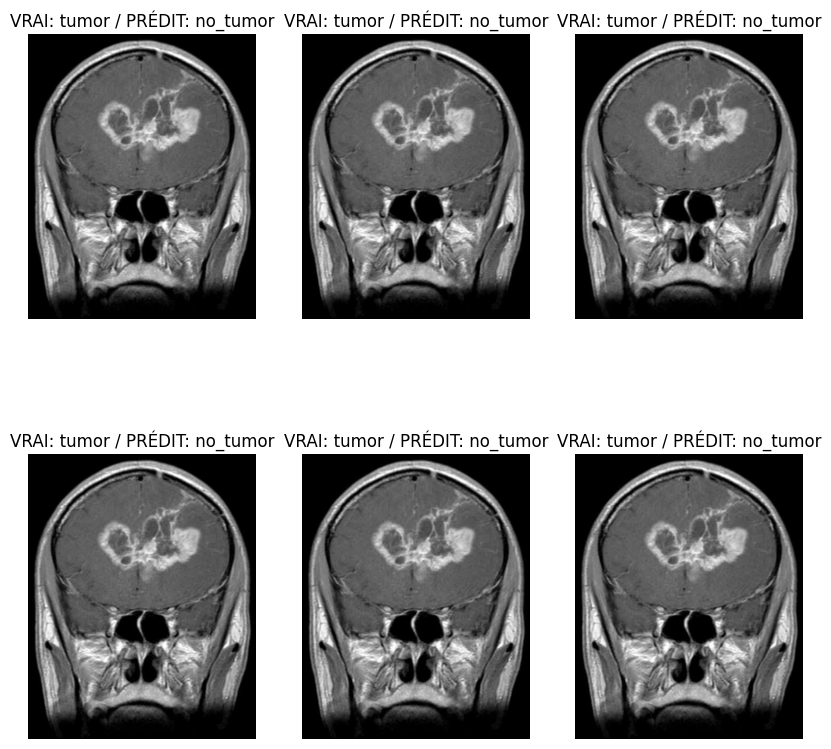

In [24]:
# Afficher quelques images
import matplotlib.pyplot as plt
from PIL import Image

n = 6  # nombre d’images à afficher

plt.figure(figsize=(10, 10))

for i, idx in enumerate(false_negatives_idx[:n]):
    img_path = image_paths[idx]
    img = Image.open(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title("VRAI: tumor / PRÉDIT: no_tumor")
    plt.axis("off")

plt.show()

L’analyse des faux négatifs montre que certaines tumeurs mal détectées présentent des formes irrégulières, diffuses et peu contrastées, rendant leur distinction difficile par rapport au tissu cérébral normal. Ces caractéristiques visuelles complexes limitent la capacité du modèle à identifier des motifs discriminants clairs. De plus, ces cas atypiques sont probablement sous-représentés dans les données d’entraînement, ce qui réduit la capacité de généralisation du modèle. La position centrale et la similarité des textures avec les structures normales renforcent cette confusion. Ces résultats mettent en évidence la nécessité d’améliorer le modèle pour mieux détecter les cas complexes en contexte médical.